In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [37]:
df = pd.read_csv('/content/archive (16).zip')

df = df[['Review Text', 'Recommended IND']]
df = df.dropna()

df.head()

,Review Text,Recommended IND
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1


In [38]:
X = df['Review Text'].astype(str)
y = df['Recommended IND']

print(X.shape)
print(y.shape)

(22641,)
(22641,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(18112,)
(18112,)
(4529,)
(4529,)


In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 5000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [41]:
max_len = 50

X_train_pad = keras.preprocessing.sequence.pad_sequences(
    X_train,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = keras.preprocessing.sequence.pad_sequences(
    X_test,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print(X_train_pad.shape)
print(y_train.shape)
print(X_test_pad.shape)
print(y_test.shape)

(18112, 50)
(18112,)
(4529, 50)
(4529,)


In [42]:
lstm_model = keras.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(units=32, activation="tanh"),
    layers.Dense(units=1, activation="sigmoid")
])

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,353 (657.63 KB)

 Trainable params: 168,353 (657.63 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [44]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8180 - loss: 0.4574 - val_accuracy: 0.8584 - val_loss: 0.3195
Epoch 2/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8727 - loss: 0.2920 - val_accuracy: 0.8824 - val_loss: 0.2620
Epoch 3/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9001 - loss: 0.2425 - val_accuracy: 0.8838 - val_loss: 0.2675
Epoch 4/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9106 - loss: 0.2191 - val_accuracy: 0.8714 - val_loss: 0.2775
Epoch 5/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9240 - loss: 0.1952 - val_accuracy: 0.8791 - val_loss: 0.2726


In [45]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)

print("Simple LSTM Test Loss:", lstm_loss)
print("Simple LSTM Test Accuracy:", lstm_acc)

Simple LSTM Test Loss: 0.30242034792900085
Simple LSTM Test Accuracy: 0.8686244487762451


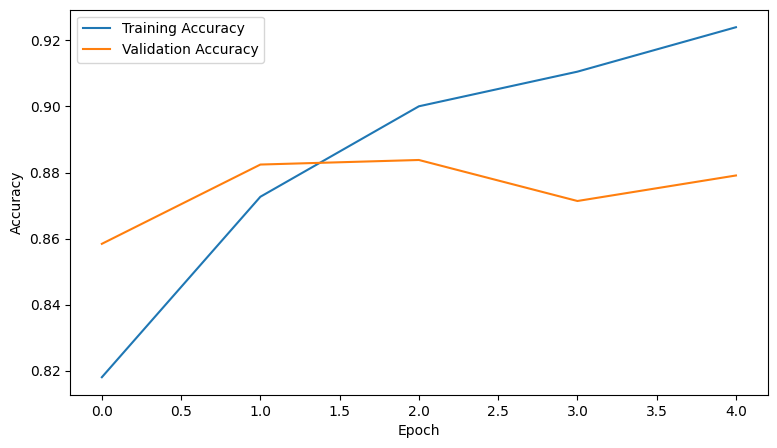

In [46]:
plt.figure(figsize=(9, 5))
plt.plot(lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

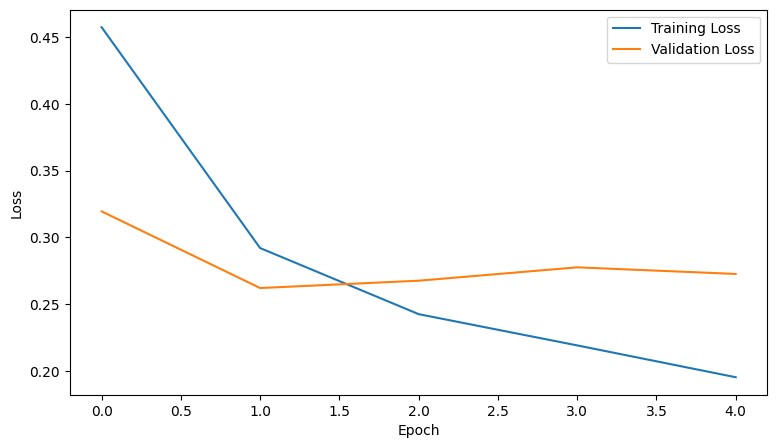

In [47]:
plt.figure(figsize=(9, 5))
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [48]:
gru_model = keras.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.GRU(units=32, activation="tanh"),
    layers.Dense(units=1, activation="sigmoid")
])

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,369 (649.88 KB)

 Trainable params: 166,369 (649.88 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [50]:
history = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8152 - loss: 0.4809 - val_accuracy: 0.8316 - val_loss: 0.3693
Epoch 2/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8627 - loss: 0.3162 - val_accuracy: 0.8890 - val_loss: 0.2661
Epoch 3/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8956 - loss: 0.2469 - val_accuracy: 0.8910 - val_loss: 0.2560
Epoch 4/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9146 - loss: 0.2145 - val_accuracy: 0.8835 - val_loss: 0.2665
Epoch 5/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9237 - loss: 0.1921 - val_accuracy: 0.8888 - val_loss: 0.2819


In [51]:
gru_loss, gru_acc = gru_model.evaluate(X_test_pad, y_test, verbose=0)

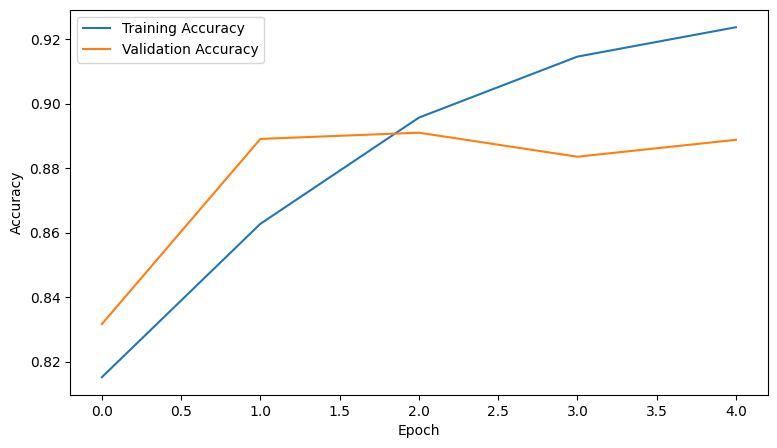

In [52]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()